# Подготовка данных


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0,66.176500
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0,28.495737
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0,34.488104
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0,36.910753
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0,31.347091


In [ ]:
df.shape

(11017, 36)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio           104

Посмотрим корреляцию между числовыми признаками на данный момент.

In [ ]:
# df.corr()['RiskScore'] - ошибка, потому что не обработаны категориальные признаки
df.select_dtypes(include=[float, int]).corr()['RiskScore']

,RiskScore
Age,-0.004648
AnnualIncome,-0.008460
CreditScore,0.002383
LoanAmount,0.011771
LoanDuration,-0.001880
NumberOfDependents,-0.023314
MonthlyDebtPayments,-0.001871
CreditCardUtilizationRate,0.005501
NumberOfOpenCreditLines,0.000730
NumberOfCreditInquiries,0.011055


Начинаем обрабатывать данные - убираем дубликаты и строки, состоящие только из NaN.

In [ ]:
df = df.drop_duplicates()
df = df.dropna(how='all')
df.shape

(10000, 36)

Рассмотрим RiskScore (целевая переменная) подробнее.


In [ ]:
df['RiskScore'].nunique()

9790

In [ ]:
df['RiskScore'].describe()

,RiskScore
count,1.000000e+04
mean,-2.995269e+04
std,1.455787e+06
min,-9.999999e+06
25%,3.253485e+01
50%,4.409630e+01
75%,6.530486e+01
max,1.000000e+07


Тип данных float - отсюда так много уникальных значений.

Сделаем обычный boxplot для оценки выбросов.

<Axes: >

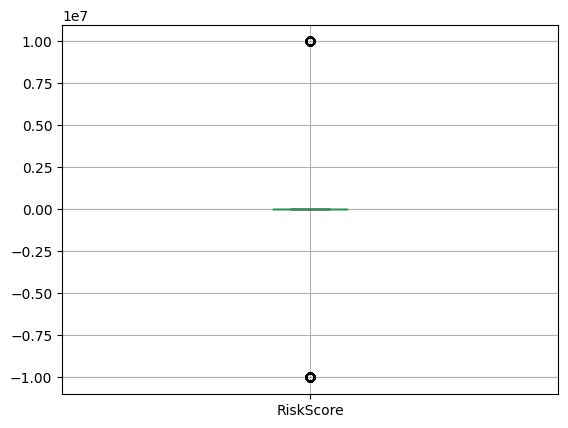

In [ ]:
df.boxplot(column='RiskScore')

Логично предположить, что RiskScore - это вероятность, диапазон значений которой будет [0;100]. Отфильтруем столбик соответствующим образом и посмотрим, что получилось.

In [ ]:
df = df[(df['RiskScore'] >= 0) & (df['RiskScore'] <= 100)]
df.shape

(9788, 36)

,RiskScore
count,9788.000000
mean,48.325333
std,17.233659
min,14.841417
25%,32.717486
50%,44.180868
75%,65.090711
max,97.597249


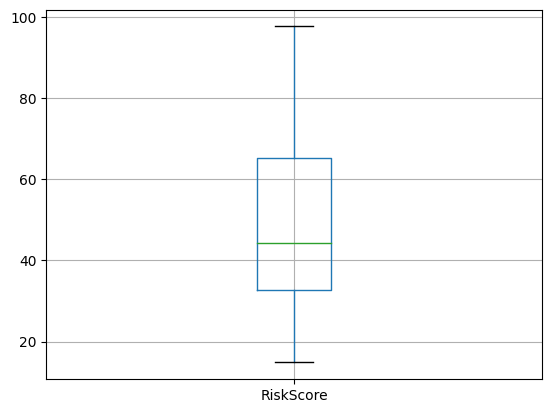

In [ ]:
df.boxplot(column='RiskScore')
df['RiskScore'].describe()

Теперь все хорошо.

Поработаем с пропусками.

In [ ]:
df.isnull().sum()

,0
ApplicationDate,0
Age,0
AnnualIncome,0
CreditScore,456
LoanAmount,456
LoanDuration,0
MaritalStatus,0
NumberOfDependents,0
HomeOwnershipStatus,0
MonthlyDebtPayments,456


In [ ]:
df[df.isna().any(axis=1)]

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
13,1997-02-26,27.0,15000.0,NaN,NaN,48.0,Married,5.0,Other,NaN,...,Employed,High School,5.0,NaN,NaN,0.343139,1097.352250,1.293082,0.0,67.304719
17,2009-06-11,43.0,43876.0,NaN,NaN,24.0,Married,3.0,Mortgage,NaN,...,Employed,Associate,20.0,NaN,NaN,0.109708,1694.354520,0.657586,0.0,48.636125
25,1983-12-01,56.0,15000.0,NaN,NaN,12.0,Married,1.0,Own,NaN,...,Employed,Bachelor,34.0,NaN,NaN,0.218868,822.309410,1.221048,0.0,70.406884
80,2019-07-05,44.0,136297.0,NaN,NaN,36.0,Single,0.0,Rent,NaN,...,Employed,High School,24.0,NaN,NaN,0.208675,1526.095455,0.245736,1.0,37.218934
95,2011-03-06,23.0,203619.0,NaN,NaN,24.0,Divorced,0.0,Mortgage,NaN,...,Employed,Associate,0.0,NaN,NaN,0.124805,815.846517,0.098233,1.0,38.026142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9917,1992-07-04,43.0,129456.0,NaN,NaN,12.0,Married,2.0,Mortgage,NaN,...,Employed,High School,25.0,NaN,NaN,0.129453,7308.696467,0.701492,0.0,40.397888
9937,1986-01-05,49.0,51227.0,NaN,NaN,24.0,Single,3.0,Rent,NaN,...,Employed,Associate,27.0,NaN,NaN,0.149436,1989.227880,0.648227,0.0,47.226112
9940,2006-10-28,43.0,15000.0,NaN,NaN,48.0,Divorced,0.0,Rent,NaN,...,Employed,High School,24.0,NaN,NaN,0.287904,347.056707,0.466445,1.0,53.624415
9972,2001-07-19,28.0,37520.0,NaN,NaN,36.0,Divorced,0.0,Mortgage,NaN,...,Employed,Bachelor,4.0,NaN,NaN,0.145322,1149.737731,0.527954,0.0,67.062142


Пока попробуем просто дропнуть строки с NaN.

In [ ]:
df = df.dropna()
df.shape

(9332, 36)

Теперь будем кодировать категориальные признаки.

In [ ]:
df.select_dtypes(include=object)

,ApplicationDate,MaritalStatus,HomeOwnershipStatus,LoanPurpose,EmploymentStatus,EducationLevel
0,2010-06-26,Divorced,Rent,Education,Employed,Associate
1,1996-09-23,Widowed,Mortgage,Home,Employed,High School
2,2015-01-19,Married,Mortgage,Education,Employed,Bachelor
3,1981-05-12,Married,Other,Debt Consolidation,Employed,High School
4,1995-05-07,Single,Rent,Debt Consolidation,Employed,Bachelor
...,...,...,...,...,...,...
9994,1986-11-30,Married,Mortgage,Debt Consolidation,Employed,Doctorate
9995,1995-06-09,Single,Other,Education,Employed,High School
9996,2000-03-10,Married,Mortgage,Auto,Employed,High School
9997,2010-04-05,Divorced,Mortgage,Education,Employed,High School


Уникальных дат очень много, поэтому One-Hot Encoding не подходит.

In [ ]:
df['ApplicationDate'].nunique()

9332

In [ ]:
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'])  # Преобразуем строковые даты в тип datetime
df['ApplicationDate'] = df['ApplicationDate'].astype(int) / 10**9  # Преобразуем в секунды
df['ApplicationDate']

,ApplicationDate
0,1.277510e+09
1,8.434368e+08
2,1.421626e+09
3,3.584736e+08
4,7.998048e+08
...,...
9994,5.336928e+08
9995,8.026560e+08
9996,9.526464e+08
9997,1.270426e+09


In [ ]:
df['ApplicationDate'].nunique()

9332

Остальное закодируем через One-Hot Encoding.



In [ ]:
df = pd.get_dummies(data=df, columns=df.select_dtypes(include=object).columns, drop_first=True)

In [ ]:
df.shape

(9332, 47)

In [ ]:
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,LoanPurpose_Debt Consolidation,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,EmploymentStatus_Self-Employed,EmploymentStatus_Unemployed,EducationLevel_Bachelor,EducationLevel_Doctorate,EducationLevel_High School,EducationLevel_Master
0,1.277510e+09,27.0,66829.0,549.0,17290.0,60.0,1.0,1095.0,0.151985,2.0,...,False,True,False,False,False,False,False,False,False,False
1,8.434368e+08,55.0,172147.0,850.0,16110.0,36.0,1.0,211.0,0.175693,3.0,...,False,False,True,False,False,False,False,False,True,False
2,1.421626e+09,51.0,300000.0,850.0,38436.0,36.0,0.0,546.0,0.444605,3.0,...,False,True,False,False,False,False,True,False,False,False
3,3.584736e+08,25.0,34683.0,847.0,19186.0,48.0,0.0,153.0,0.188452,7.0,...,True,False,False,False,False,False,False,False,True,False
4,7.998048e+08,55.0,300000.0,850.0,30437.0,48.0,2.0,562.0,0.273431,3.0,...,True,False,False,False,False,False,True,False,False,False


Посмотрим на итоговую корреляцию признаков с RiskScore.

In [ ]:
df.corr()['RiskScore']

,RiskScore
ApplicationDate,0.002558
Age,-0.042744
AnnualIncome,-0.757874
CreditScore,-0.785429
LoanAmount,0.079041
LoanDuration,0.025265
NumberOfDependents,0.008190
MonthlyDebtPayments,0.017922
CreditCardUtilizationRate,0.053080
NumberOfOpenCreditLines,-0.001151


In [ ]:
# correlations = df.corr()

# columns_to_keep = correlations.index[(correlations['RiskScore'] > 0.4) | (correlations['RiskScore'] < -0.4)].tolist()

# df = df[columns_to_keep]
# df.corr()['RiskScore']

# Разделение данных, нормализация, обучение модели и оценка модели

In [ ]:
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
scaler = StandardScaler()
X = df.drop('RiskScore', axis=1)

y = df['RiskScore']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

scaler.fit(X_train, y_train)

X_train = scaler.transform(X_train)

X_test = scaler.transform(X_test)

params = {
    'alpha' : [0.01, 0.02, 0.03, 0.04, 0.05, 0.06],
    'l1_ratio' : [0.95, 0.96, 0.97, 0.98, 0.99, 1.0]
}

grid_model = GridSearchCV(
    estimator=ElasticNet(),
    param_grid=params,
    cv=4,
    scoring='r2',
    verbose=2,
    n_jobs=-1
)

grid_model.fit(X_train, y_train)

predict = grid_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, predict))

print("R2_Score:", r2_score(y_test, predict))

Fitting 4 folds for each of 36 candidates, totalling 144 fits
MSE: 19.445208549190387
R2_Score: 0.9346016687778304


In [ ]:
grid_model.best_estimator_

ElasticNet(alpha=0.03, l1_ratio=1.0)

# Предсказание и выгрузка

In [ ]:
df_test = pd.read_csv('test.csv')
id = df_test["ID"]
df_test = df_test.drop('ID', axis=1)

df_test['ApplicationDate'] = pd.to_datetime(df_test['ApplicationDate'])
df_test['ApplicationDate'] = df_test['ApplicationDate'].astype(int) / 10**9
df_test['ApplicationDate']

df_test = pd.get_dummies(data=df_test, columns=df_test.select_dtypes(include=object).columns, drop_first=True)

scaler = StandardScaler()
scaler.fit(df_test)
df_test = scaler.transform(df_test)

predict = grid_model.predict(df_test)

result = pd.DataFrame({'ID': id, 'RiskScore': predict})
result.to_csv('predictions.csv', index=False)